# Brazilian Port Lead Time — Quantile Regression & Uncertainty

Notebook 01 introduced the public Brazilian port-call dataset with EDA and a point-prediction baseline. This second notebook asks a different question: instead of predicting only one expected port-stay duration, can we estimate a range of plausible outcomes?

Port stay has a long right tail. Many vessel calls finish in a moderate number of hours, while a smaller but operationally important share stays much longer. A single point prediction can hide that risk.

Quantile regression gives several conditional views of the same prediction problem:

- **P50**: a central conditional estimate. Roughly half of comparable outcomes are expected to be below it, subject to calibration.
- **P90**: a duration that the model expects approximately 90% of comparable outcomes not to exceed, subject to calibration.
- **P95**: a more conservative upper quantile.

These are not deterministic confidence intervals or guaranteed service levels. They are model estimates that must be checked empirically.

Links:

- Dataset: https://www.kaggle.com/datasets/tiagoalberione/brazilian-port-lead-time-2023-2025
- GitHub repository: https://github.com/tiagoalberione/port-leadtime-prediction

## 1. Imports and Configuration

The notebook uses pandas, NumPy, matplotlib, and scikit-learn only. The random state is fixed for reproducibility.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_pinball_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


RANDOM_STATE = 42
TARGET = "t_total_port_stay_h"
DATE_COL = "arrival_port_ts"
ID_COL = "port_call_id"
SPLIT_COL = "split"
BASE_COLUMNS = [ID_COL, DATE_COL, TARGET, SPLIT_COL]
MODEL_FILE = "brazilian_port_calls_model_ready_2023_2025.csv"
SPLIT_ORDER = ["train", "validation", "calibration", "final_test"]
DEVELOPMENT_SPLITS = ["train", "validation", "calibration"]
QUANTILES = {"P50": 0.50, "P90": 0.90, "P95": 0.95}

NOTEBOOK_START = time.perf_counter()

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

## 2. Load the Public CSV

The public Kaggle dataset contains one runtime data file: `brazilian_port_calls_model_ready_2023_2025.csv`. On Kaggle, the helper searches recursively under `/kaggle/input`. Locally, it falls back to `kaggle/dataset/output/`.

In [2]:
def find_input_file(filename, local_relative_dirs):
    candidates = []
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(sorted(kaggle_input.rglob(filename)))

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        for relative_dir in local_relative_dirs:
            candidates.append(base / relative_dir / filename)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    searched = "\n".join(str(path) for path in candidates[:20])
    raise FileNotFoundError(f"Could not find {filename}. First searched locations:\n{searched}")


def display_path(path):
    path = Path(path).resolve()
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        try:
            return str(path.relative_to(base))
        except ValueError:
            pass
    return str(path)


model_path = find_input_file(MODEL_FILE, [Path("kaggle/dataset/output"), Path(".")])
df = pd.read_csv(model_path, parse_dates=[DATE_COL])

print(f"Loaded model-ready data from: {display_path(model_path)}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Date range: {df[DATE_COL].min()} to {df[DATE_COL].max()}")
print(f"Target: {TARGET}")
print("\nSplit counts:")
print(df[SPLIT_COL].value_counts().reindex(SPLIT_ORDER).to_string())

predictors = [column for column in df.columns if column not in BASE_COLUMNS]

required_columns = set(BASE_COLUMNS)
missing_required = sorted(required_columns - set(df.columns))
assert not missing_required, f"Missing required columns: {missing_required}"
assert len(df) == 129_625, f"Expected 129,625 rows, found {len(df):,}."
assert df.shape[1] == 124, f"Expected 124 columns, found {df.shape[1]:,}."
assert len(predictors) == 120, f"Expected 120 predictors, found {len(predictors):,}."
assert df[TARGET].notna().all(), "The target should be complete."
assert (df[TARGET] >= 0).all(), "The target should be non-negative."
assert set(df[SPLIT_COL].dropna()) == set(SPLIT_ORDER), "Unexpected split labels."
assert df[SPLIT_COL].notna().all(), "All rows should have an official split."

split_bounds = {
    "train": ("2023-01-01", "2024-07-01"),
    "validation": ("2024-07-01", "2025-01-01"),
    "calibration": ("2025-01-01", "2025-07-01"),
    "final_test": ("2025-07-01", "2026-01-01"),
}
for split_name, (start, end) in split_bounds.items():
    part = df[df[SPLIT_COL] == split_name]
    assert ((part[DATE_COL] >= start) & (part[DATE_COL] < end)).all(), f"{split_name} has dates outside bounds."

Loaded model-ready data from: kaggle\dataset\output\brazilian_port_calls_model_ready_2023_2025.csv
Shape: 129,625 rows x 124 columns
Date range: 2023-01-01 00:08:00 to 2025-12-31 23:00:00
Target: t_total_port_stay_h

Split counts:
split
train          66909
validation     20362
calibration    21352
final_test     21002


## 3. Why Quantiles?

This section uses only the development period: `train`, `validation`, and `calibration`. The final-test split remains untouched until the locked final evaluation.

For a quantile level q, pinball loss penalizes underprediction and overprediction asymmetrically. At P90, underpredicting a long stay is penalized more heavily than overpredicting by the same amount, which nudges the model toward an upper conditional estimate.

,t_total_port_stay_h
count,"108,623.00"
mean,71.24
median / P50,38.17
P90,163.83
P95,255.60
P99,531.06
max,"1,280.08"
P90 minus P50,125.66
P95 minus P50,217.43


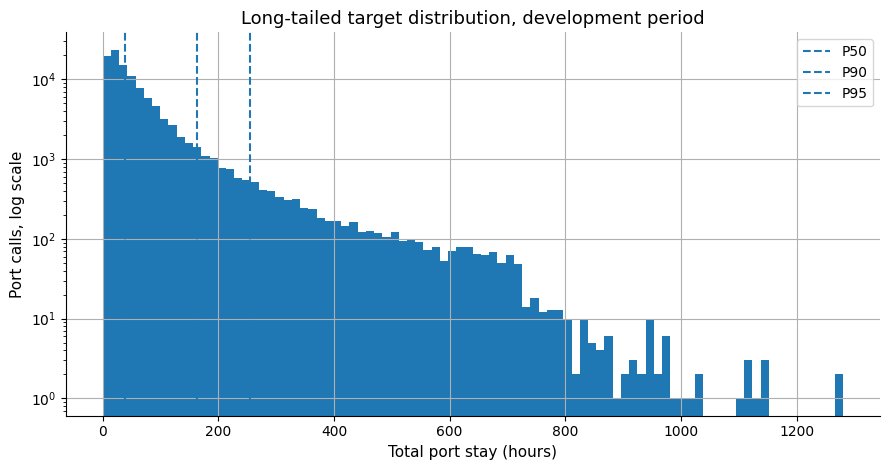

In [3]:
development_df = df[df[SPLIT_COL].isin(DEVELOPMENT_SPLITS)].copy()
target_dev = development_df[TARGET]

target_summary = pd.Series(
    {
        "count": target_dev.count(),
        "mean": target_dev.mean(),
        "median / P50": target_dev.quantile(0.50),
        "P90": target_dev.quantile(0.90),
        "P95": target_dev.quantile(0.95),
        "P99": target_dev.quantile(0.99),
        "max": target_dev.max(),
        "P90 minus P50": target_dev.quantile(0.90) - target_dev.quantile(0.50),
        "P95 minus P50": target_dev.quantile(0.95) - target_dev.quantile(0.50),
    },
    name=TARGET,
).to_frame()
display(target_summary.style.format("{:,.2f}"))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(target_dev, bins=90)
ax.set_yscale("log")
ax.axvline(target_dev.quantile(0.50), linestyle="--", label="P50")
ax.axvline(target_dev.quantile(0.90), linestyle="--", label="P90")
ax.axvline(target_dev.quantile(0.95), linestyle="--", label="P95")
ax.set_title("Long-tailed target distribution, development period")
ax.set_xlabel("Total port stay (hours)")
ax.set_ylabel("Port calls, log scale")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Preprocessing

The feature definition follows Notebook 01: all model-ready CSV columns except `port_call_id`, `arrival_port_ts`, `t_total_port_stay_h`, and `split`.

Categorical variables are imputed with a constant missing label and ordinal-encoded with unknown-value handling. Numeric and boolean variables use median imputation. Ordinal encoding is a lightweight baseline choice; the integer codes do not imply a meaningful natural ordering between categories, and more specialized categorical handling is left for future experiments.

In [4]:
train_df = df[df[SPLIT_COL] == "train"].copy()
validation_df = df[df[SPLIT_COL] == "validation"].copy()
calibration_df = df[df[SPLIT_COL] == "calibration"].copy()

raw_X_train = train_df[predictors]
categorical_features = raw_X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = [column for column in predictors if column not in categorical_features]

print(f"Predictors used: {len(predictors)}")
print(f"Numeric/bool predictors: {len(numeric_features)}")
print(f"Categorical predictors: {len(categorical_features)}")
display(pd.DataFrame({"feature": predictors}))


def make_model_matrix(frame):
    X = frame[predictors].copy()
    for column in categorical_features:
        X[column] = X[column].astype("object").where(X[column].notna(), np.nan)
    return X


def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("numeric", SimpleImputer(strategy="median"), numeric_features),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                        (
                            "encoder",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                encoded_missing_value=-2,
                            ),
                        ),
                    ]
                ),
                categorical_features,
            ),
        ],
        sparse_threshold=0.0,
    )

Predictors used: 120
Numeric/bool predictors: 115
Categorical predictors: 5


,feature
0,port
1,region
2,state
3,arrival_shift
4,arrival_season
...,...
115,opmix_carga_share_prev_7d
116,opmix_descarga_share_prev_7d
117,opmix_fundeio_share_prev_7d
118,opmix_offshore_share_prev_7d


## 5. Quantile Models

We train three separate `HistGradientBoostingRegressor` models with quantile loss: P50, P90, and P95. The target is modeled on `log1p(hours)` and converted back to hours with `expm1`, which keeps predictions non-negative and makes the long tail easier for this compact baseline.

There is no grid search or final-test tuning here.

In [5]:
hgb_quantile_params = {
    "learning_rate": 0.08,
    "max_iter": 180,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 40,
    "l2_regularization": 0.10,
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 10,
    "random_state": RANDOM_STATE,
}


def make_quantile_pipeline(quantile):
    model = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=quantile,
        **hgb_quantile_params,
    )
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", model),
        ]
    )


def fit_quantile_pipelines(train_frame):
    fitted = {}
    X_train = make_model_matrix(train_frame)
    y_train_log = np.log1p(train_frame[TARGET].to_numpy(dtype=float))
    for label, quantile in QUANTILES.items():
        pipeline = make_quantile_pipeline(quantile)
        pipeline.fit(X_train, y_train_log)
        fitted[label] = pipeline
    return fitted


def predict_quantiles(models, frame):
    X = make_model_matrix(frame)
    predictions = pd.DataFrame(index=frame.index)
    for label, model in models.items():
        predictions[label] = np.clip(np.expm1(model.predict(X)), 0, None)
    raw_predictions = predictions.copy()
    predictions[["P50", "P90", "P95"]] = np.maximum.accumulate(
        predictions[["P50", "P90", "P95"]].to_numpy(),
        axis=1,
    )
    return predictions, raw_predictions


fit_start = time.perf_counter()
dev_models = fit_quantile_pipelines(train_df)
validation_pred, validation_pred_raw = predict_quantiles(dev_models, validation_df)
calibration_pred, calibration_pred_raw = predict_quantiles(dev_models, calibration_df)
dev_fit_seconds = time.perf_counter() - fit_start

print(f"Development quantile models fit time: {dev_fit_seconds:.1f} seconds")
print("Fixed quantile model parameters:")
display(pd.Series(hgb_quantile_params, name="value").to_frame())

Development quantile models fit time: 13.5 seconds
Fixed quantile model parameters:


,value
learning_rate,0.08
max_iter,180
max_leaf_nodes,31
min_samples_leaf,40
l2_regularization,0.1
early_stopping,True
validation_fraction,0.1
n_iter_no_change,10
random_state,42


## 6. Development Protocol and Quantile Metrics

The models above are fit on `train`. We inspect quantile behavior on `validation` and empirical coverage on `calibration`. No calibration adjustment is applied in this introductory notebook; the calibration split is used only to diagnose behavior before the final locked evaluation.

Empirical coverage is the share of observations with `actual <= predicted_quantile`. It does not need to equal the nominal quantile exactly, especially with finite samples, drift, and a compact baseline model.

,dataset,quantile,target_coverage,empirical_coverage,pinball_loss
0,validation,P50,50%,49.7%,22.55
1,validation,P90,90%,87.9%,17.87
2,validation,P95,95%,92.9%,12.69
3,calibration,P50,50%,52.8%,19.74
4,calibration,P90,90%,89.7%,16.05
5,calibration,P95,95%,94.1%,11.50


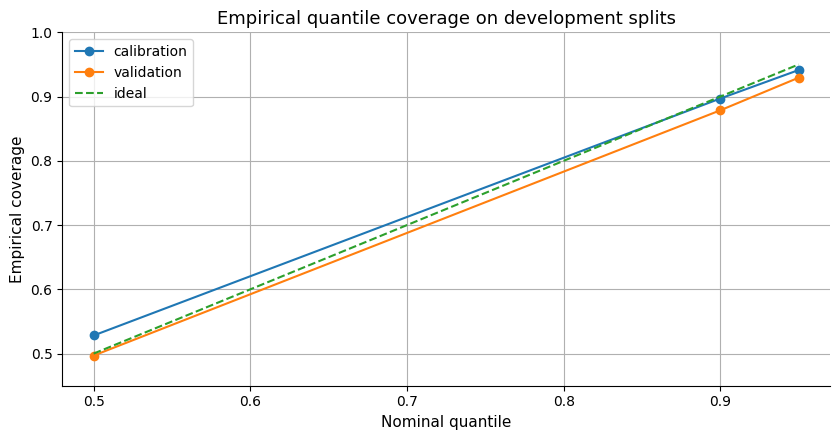

In [6]:
def quantile_metrics(y_true, predictions, dataset_name):
    rows = []
    y = y_true.to_numpy(dtype=float)
    for label, quantile in QUANTILES.items():
        pred = predictions[label].to_numpy(dtype=float)
        rows.append(
            {
                "dataset": dataset_name,
                "quantile": label,
                "target_coverage": quantile,
                "empirical_coverage": np.mean(y <= pred),
                "pinball_loss": mean_pinball_loss(y, pred, alpha=quantile),
            }
        )
    return pd.DataFrame(rows)


development_metrics = pd.concat(
    [
        quantile_metrics(validation_df[TARGET], validation_pred, "validation"),
        quantile_metrics(calibration_df[TARGET], calibration_pred, "calibration"),
    ],
    ignore_index=True,
)
display(
    development_metrics.style.format(
        {
            "target_coverage": "{:.0%}",
            "empirical_coverage": "{:.1%}",
            "pinball_loss": "{:,.2f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for dataset_name, part in development_metrics.groupby("dataset"):
    ax.plot(part["target_coverage"], part["empirical_coverage"], marker="o", label=dataset_name)
ax.plot([0.5, 0.95], [0.5, 0.95], linestyle="--", label="ideal")
ax.set_title("Empirical quantile coverage on development splits")
ax.set_xlabel("Nominal quantile")
ax.set_ylabel("Empirical coverage")
ax.set_xlim(0.48, 0.97)
ax.set_ylim(0.45, 1.00)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Quantile Crossing

Separate quantile models can occasionally cross, for example P90 below P50. We diagnose raw crossings and then apply a simple monotonic rearrangement for reporting: P90 is at least P50, and P95 is at least P90. This rule is fixed before the final-test evaluation and is not fitted on `final_test`.

In [7]:
def crossing_summary(raw_predictions, dataset_name):
    crossing = (raw_predictions["P50"] > raw_predictions["P90"]) | (raw_predictions["P90"] > raw_predictions["P95"])
    return {
        "dataset": dataset_name,
        "crossing_rows": int(crossing.sum()),
        "crossing_rate": float(crossing.mean()),
    }


crossing_dev = pd.DataFrame(
    [
        crossing_summary(validation_pred_raw, "validation"),
        crossing_summary(calibration_pred_raw, "calibration"),
    ]
)
display(crossing_dev.style.format({"crossing_rows": "{:,.0f}", "crossing_rate": "{:.2%}"}))

,dataset,crossing_rows,crossing_rate
0,validation,567,2.78%
1,calibration,573,2.68%


## 8. Uncertainty Width

The gap between upper quantiles and P50 is a practical uncertainty signal. Wider P90-P50 or P95-P50 gaps mean the model sees more conditional uncertainty for that call.

,P90_minus_P50,P95_minus_P50
median,72.39,119.72
P75,116.94,188.61
P90,160.86,240.40
max,860.93,860.93


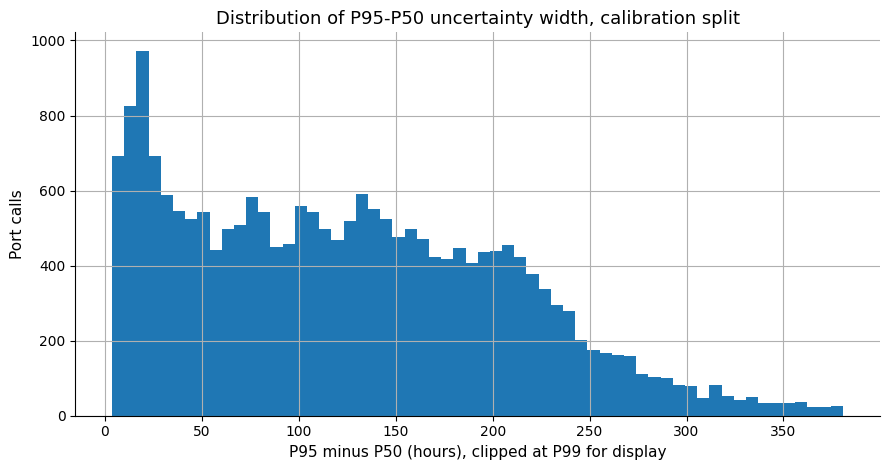

In [8]:
def add_widths(predictions):
    out = predictions.copy()
    out["P90_minus_P50"] = out["P90"] - out["P50"]
    out["P95_minus_P50"] = out["P95"] - out["P50"]
    return out


calibration_uncertainty = add_widths(calibration_pred)
width_summary = calibration_uncertainty[["P90_minus_P50", "P95_minus_P50"]].agg(
    ["median", lambda x: x.quantile(0.75), lambda x: x.quantile(0.90), "max"]
)
width_summary.index = ["median", "P75", "P90", "max"]
display(width_summary.style.format("{:,.2f}"))

fig, ax = plt.subplots(figsize=(9, 4.8))
p99_width = calibration_uncertainty["P95_minus_P50"].quantile(0.99)
ax.hist(
    calibration_uncertainty.loc[calibration_uncertainty["P95_minus_P50"] <= p99_width, "P95_minus_P50"],
    bins=60,
)
ax.set_title("Distribution of P95-P50 uncertainty width, calibration split")
ax.set_xlabel("P95 minus P50 (hours), clipped at P99 for display")
ax.set_ylabel("Port calls")
plt.tight_layout()
plt.show()

## 9. Uncertainty Width and Realized Duration

This diagnostic uses only validation and calibration during development. It asks whether calls that turned out to be longer also tended to receive wider predicted uncertainty. This is an association, not a causal claim.

,dataset,actual_stay_bin,rows,mae_p50_h,median_width_p90_p50_h,median_width_p95_p50_h
0,validation,<= 1 day,"6,097",15.08,35.44,59.63
1,validation,1-3 days,"7,975",17.03,72.07,122.57
2,validation,3-7 days,"4,045",43.32,101.68,166.42
3,validation,7-14 days,"1,535",148.00,138.20,212.90
4,validation,> 14 days,710,406.11,187.85,268.81
5,calibration,<= 1 day,"7,298",14.30,29.92,51.34
6,calibration,1-3 days,"8,019",16.81,72.01,121.32
7,calibration,3-7 days,"4,110",41.66,101.00,163.20
8,calibration,7-14 days,"1,359",147.92,130.51,201.54
9,calibration,> 14 days,566,409.24,153.86,231.67


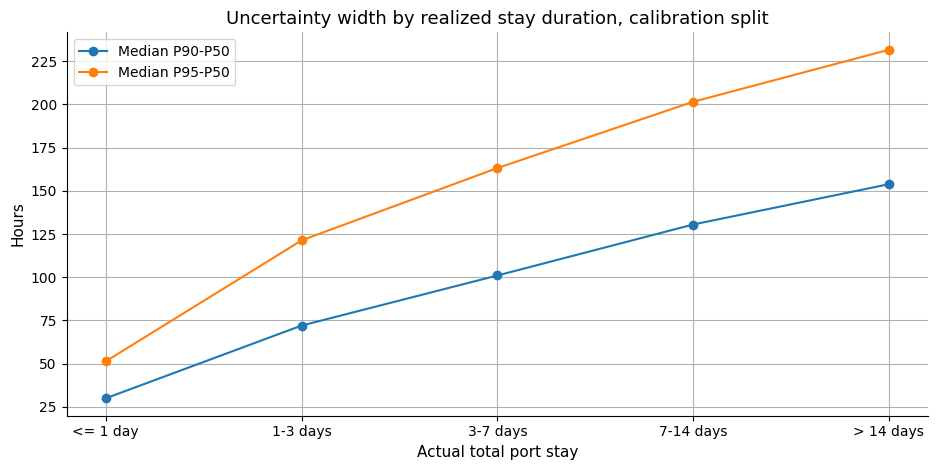

In [9]:
def bin_error_and_widths(frame, predictions, dataset_name):
    out = frame[[TARGET]].copy()
    out["P50"] = predictions["P50"].to_numpy()
    out["P90_minus_P50"] = predictions["P90"].to_numpy() - predictions["P50"].to_numpy()
    out["P95_minus_P50"] = predictions["P95"].to_numpy() - predictions["P50"].to_numpy()
    out["abs_error_p50"] = np.abs(out[TARGET] - out["P50"])
    out["actual_stay_bin"] = pd.cut(
        out[TARGET],
        bins=[0, 24, 72, 168, 336, np.inf],
        labels=["<= 1 day", "1-3 days", "3-7 days", "7-14 days", "> 14 days"],
        include_lowest=True,
        right=True,
    )
    summary = (
        out.groupby("actual_stay_bin", observed=False)
        .agg(
            rows=(TARGET, "size"),
            mae_p50_h=("abs_error_p50", "mean"),
            median_width_p90_p50_h=("P90_minus_P50", "median"),
            median_width_p95_p50_h=("P95_minus_P50", "median"),
        )
        .reset_index()
    )
    summary.insert(0, "dataset", dataset_name)
    return summary


dev_width_by_bin = pd.concat(
    [
        bin_error_and_widths(validation_df, validation_pred, "validation"),
        bin_error_and_widths(calibration_df, calibration_pred, "calibration"),
    ],
    ignore_index=True,
)
display(
    dev_width_by_bin.style.format(
        {
            "rows": "{:,.0f}",
            "mae_p50_h": "{:,.2f}",
            "median_width_p90_p50_h": "{:,.2f}",
            "median_width_p95_p50_h": "{:,.2f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
plot_data = dev_width_by_bin[dev_width_by_bin["dataset"] == "calibration"].copy()
ax.plot(plot_data["actual_stay_bin"].astype(str), plot_data["median_width_p90_p50_h"], marker="o", label="Median P90-P50")
ax.plot(plot_data["actual_stay_bin"].astype(str), plot_data["median_width_p95_p50_h"], marker="o", label="Median P95-P50")
ax.set_title("Uncertainty width by realized stay duration, calibration split")
ax.set_xlabel("Actual total port stay")
ax.set_ylabel("Hours")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Locked Final Evaluation

All choices are now frozen: feature definition, preprocessing, quantile levels, model family, model parameters, log target transform, and monotonic post-processing.

We fit the same final quantile pipelines on `train + validation + calibration` and evaluate once on `final_test`. The results below should not be used to revise the model in this notebook.

,dataset,quantile,target_coverage,empirical_coverage,pinball_loss
0,final_test,P50,50%,49.7%,19.31
1,final_test,P90,90%,89.4%,15.05
2,final_test,P95,95%,94.5%,10.57


,dataset,crossing_rows,crossing_rate
0,final_test,581,2.77%


,hours
median_P90_minus_P50,70.99
median_P95_minus_P50,117.90


,dataset,actual_stay_bin,rows,mae_p50_h,median_width_p90_p50_h,median_width_p95_p50_h
0,final_test,<= 1 day,"6,430",13.86,37.20,59.10
1,final_test,1-3 days,"8,581",16.58,66.09,110.24
2,final_test,3-7 days,"4,066",43.43,103.62,161.16
3,final_test,7-14 days,"1,363",141.42,139.67,215.02
4,final_test,> 14 days,562,374.20,184.03,270.10


Final quantile models fit time: 15.6 seconds


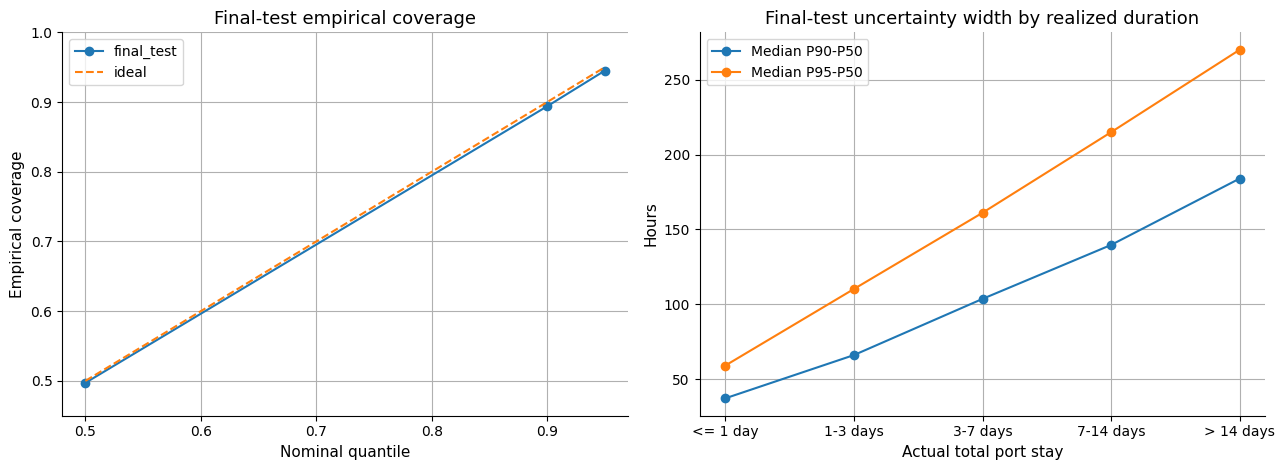

In [10]:
development_for_final = df[df[SPLIT_COL].isin(DEVELOPMENT_SPLITS)].copy()
final_holdout_df = df[df[SPLIT_COL] == "final_test"].copy()

final_fit_start = time.perf_counter()
final_models = fit_quantile_pipelines(development_for_final)
final_pred, final_pred_raw = predict_quantiles(final_models, final_holdout_df)
final_fit_seconds = time.perf_counter() - final_fit_start

final_metrics = quantile_metrics(final_holdout_df[TARGET], final_pred, "final_test")
final_crossing = pd.DataFrame([crossing_summary(final_pred_raw, "final_test")])
final_uncertainty = add_widths(final_pred)

final_width_summary = pd.Series(
    {
        "median_P90_minus_P50": final_uncertainty["P90_minus_P50"].median(),
        "median_P95_minus_P50": final_uncertainty["P95_minus_P50"].median(),
    },
    name="hours",
).to_frame()
final_width_by_bin = bin_error_and_widths(final_holdout_df, final_pred, "final_test")

display(
    final_metrics.style.format(
        {
            "target_coverage": "{:.0%}",
            "empirical_coverage": "{:.1%}",
            "pinball_loss": "{:,.2f}",
        }
    )
)
display(final_crossing.style.format({"crossing_rows": "{:,.0f}", "crossing_rate": "{:.2%}"}))
display(final_width_summary.style.format("{:,.2f}"))
display(
    final_width_by_bin.style.format(
        {
            "rows": "{:,.0f}",
            "mae_p50_h": "{:,.2f}",
            "median_width_p90_p50_h": "{:,.2f}",
            "median_width_p95_p50_h": "{:,.2f}",
        }
    )
)
print(f"Final quantile models fit time: {final_fit_seconds:.1f} seconds")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(final_metrics["target_coverage"], final_metrics["empirical_coverage"], marker="o", label="final_test")
axes[0].plot([0.5, 0.95], [0.5, 0.95], linestyle="--", label="ideal")
axes[0].set_title("Final-test empirical coverage")
axes[0].set_xlabel("Nominal quantile")
axes[0].set_ylabel("Empirical coverage")
axes[0].set_xlim(0.48, 0.97)
axes[0].set_ylim(0.45, 1.00)
axes[0].legend()

axes[1].plot(
    final_width_by_bin["actual_stay_bin"].astype(str),
    final_width_by_bin["median_width_p90_p50_h"],
    marker="o",
    label="Median P90-P50",
)
axes[1].plot(
    final_width_by_bin["actual_stay_bin"].astype(str),
    final_width_by_bin["median_width_p95_p50_h"],
    marker="o",
    label="Median P95-P50",
)
axes[1].set_title("Final-test uncertainty width by realized duration")
axes[1].set_xlabel("Actual total port stay")
axes[1].set_ylabel("Hours")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Example Predictions

These final-test examples are selected deterministically by fixed random sampling. They are not hand-picked to look good or bad, and no unnecessary identifiers are displayed.

In [11]:
example = final_holdout_df[[TARGET]].copy()
example["P50"] = final_pred["P50"].to_numpy()
example["P90"] = final_pred["P90"].to_numpy()
example["P95"] = final_pred["P95"].to_numpy()
example["P90_minus_P50"] = example["P90"] - example["P50"]
example["P95_minus_P50"] = example["P95"] - example["P50"]
example = (
    example.rename(columns={TARGET: "actual_stay_h"})
    .sample(n=10, random_state=RANDOM_STATE)
    .sort_values("actual_stay_h")
    .reset_index(drop=True)
)
display(example.style.format("{:,.2f}"))

,actual_stay_h,P50,P90,P95,P90_minus_P50,P95_minus_P50
0,14.63,11.82,17.79,22.43,5.97,10.61
1,24.50,18.03,25.96,32.44,7.93,14.41
2,26.50,28.93,47.66,61.76,18.72,32.83
3,31.25,28.02,102.45,177.25,74.43,149.23
4,35.17,18.10,37.68,50.57,19.58,32.47
5,35.93,14.31,31.45,45.04,17.13,30.73
6,37.47,44.90,146.86,264.29,101.96,219.39
7,58.97,91.28,229.12,304.66,137.84,213.37
8,72.10,47.85,94.94,153.67,47.09,105.82
9,95.17,43.73,112.33,166.49,68.60,122.76


## 12. Conclusions

Point forecasts are useful, but they do not capture the uncertainty created by a long-tailed port-stay target. P50, P90, and P95 provide different operational perspectives: central tendency, a high expected duration, and a more conservative upper quantile.

The important habit is to check empirical coverage rather than assume it. Wider P90-P50 and P95-P50 gaps indicate higher modeled uncertainty, and long-duration calls remain a major challenge for compact baseline models. The next public notebook can translate probabilistic lead-time estimates into a supply-chain safety-stock scenario.

Links:

- Dataset: https://www.kaggle.com/datasets/tiagoalberione/brazilian-port-lead-time-2023-2025
- GitHub repository: https://github.com/tiagoalberione/port-leadtime-prediction

In [12]:
elapsed = time.perf_counter() - NOTEBOOK_START
print(f"Notebook runtime measured inside Python: {elapsed:.1f} seconds")

Notebook runtime measured inside Python: 31.7 seconds
